SAAS REVENUE INTELLIGENCE

CUSTOMER AND CHURN ANALYSIS

Business Objective:
Analyze customer health,
revenue customer behavior,
retention,
and churn patterns.
Focus on customers contributing revenue.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("LIBRARIES LOADED")

LIBRARIES LOADED


In [2]:
CUSTOMERS = pd.read_csv("../01_Data/customers.csv")

INVOICES = pd.read_csv("../01_Data/invoices.csv")

SUBSCRIPTIONS = pd.read_csv("../01_Data/subscriptions.csv")

CHURN_EVENTS = pd.read_csv("../01_Data/Churn_events.csv")

SUBSCRIPTION_PLANS = pd.read_csv("../01_Data/subscription_plans.csv")

In [3]:
CUSTOMER_HEALTH = (
    CUSTOMERS
    .merge(
        SUBSCRIPTIONS,
        on="customer_id",
        how="left"
    )
)

CUSTOMER_HEALTH.head()

,customer_id,signup_date,company_size,industry,acquisition_channel,country,subscription_id,start_date,end_date,status,plan_id
0,1,11/05/23,medium,finance,referral,Germany,1,11/05/23,NaN,active,5
1,2,25/04/23,large,health,referral,US,2,25/04/23,25/11/23,churned,1
2,3,18/03/23,large,retail,organic,Germany,3,18/03/23,NaN,active,1
3,4,08/05/23,large,retail,ads,UK,4,08/05/23,08/10/23,churned,1
4,5,28/05/23,small,retail,organic,Germany,5,28/05/23,28/11/23,churned,1


In [4]:
TOTAL_CUSTOMERS = (
    CUSTOMERS["customer_id"]
    .nunique()
)

print(
    "TOTAL CUSTOMERS:",
    TOTAL_CUSTOMERS
)

TOTAL CUSTOMERS: 25000


In [5]:
REVENUE_CUSTOMERS = (
    INVOICES["customer_id"]
    .nunique()
)

print(
    "REVENUE CUSTOMERS:",
    REVENUE_CUSTOMERS
)

REVENUE CUSTOMERS: 8027


In [6]:
REVENUE_CUSTOMER_IDS = (
    INVOICES["customer_id"]
    .unique()
)

REVENUE_SUBSCRIPTIONS = (
    SUBSCRIPTIONS[
        SUBSCRIPTIONS["customer_id"]
        .isin(REVENUE_CUSTOMER_IDS)
    ]
)

ACTIVE_REVENUE_CUSTOMERS = (
    REVENUE_SUBSCRIPTIONS[
        REVENUE_SUBSCRIPTIONS["status"]=="active"
    ]["customer_id"]
    .nunique()
)

CHURNED_REVENUE_CUSTOMERS = (
    REVENUE_SUBSCRIPTIONS[
        REVENUE_SUBSCRIPTIONS["status"]=="churned"
    ]["customer_id"]
    .nunique()
)

print(
    "ACTIVE REVENUE CUSTOMERS:",
    ACTIVE_REVENUE_CUSTOMERS
)

print(
    "CHURNED REVENUE CUSTOMERS:",
    CHURNED_REVENUE_CUSTOMERS
)

ACTIVE REVENUE CUSTOMERS: 5469
CHURNED REVENUE CUSTOMERS: 2558


In [7]:
print(
    "TOTAL REVENUE CUSTOMERS:",
    REVENUE_CUSTOMERS
)

print(
    "ACTIVE + CHURNED:",
    ACTIVE_REVENUE_CUSTOMERS +
    CHURNED_REVENUE_CUSTOMERS
)

TOTAL REVENUE CUSTOMERS: 8027
ACTIVE + CHURNED: 8027


In [8]:
CHURN_RATE = (
    CHURNED_REVENUE_CUSTOMERS
    /
    REVENUE_CUSTOMERS
) * 100

print(
    "CHURN RATE:",
    round(CHURN_RATE,2),
    "%"
)

CHURN RATE: 31.87 %


In [9]:
SUMMARY = pd.DataFrame({

    "METRIC":[
        "Total Customers",
        "Revenue Customers",
        "Active Revenue Customers",
        "Churned Revenue Customers",
        "Churn Rate"
    ],

    "VALUE":[
        TOTAL_CUSTOMERS,
        REVENUE_CUSTOMERS,
        ACTIVE_REVENUE_CUSTOMERS,
        CHURNED_REVENUE_CUSTOMERS,
        round(CHURN_RATE,2)
    ]
})

SUMMARY

,METRIC,VALUE
0,Total Customers,25000.00
1,Revenue Customers,8027.00
2,Active Revenue Customers,5469.00
3,Churned Revenue Customers,2558.00
4,Churn Rate,31.87


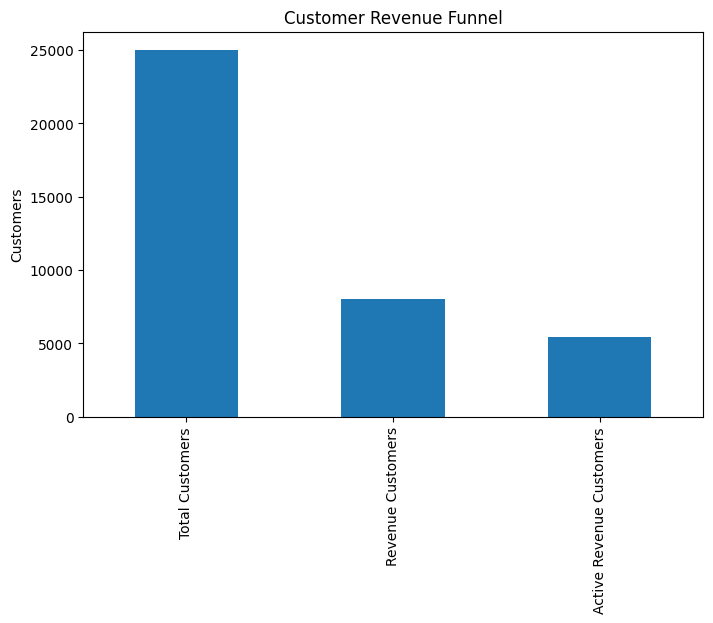

In [10]:
FUNNEL = pd.Series({

    "Total Customers":
    TOTAL_CUSTOMERS,

    "Revenue Customers":
    REVENUE_CUSTOMERS,

    "Active Revenue Customers":
    ACTIVE_REVENUE_CUSTOMERS

})

FUNNEL.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Customer Revenue Funnel"
)

plt.ylabel(
    "Customers"
)

plt.show()

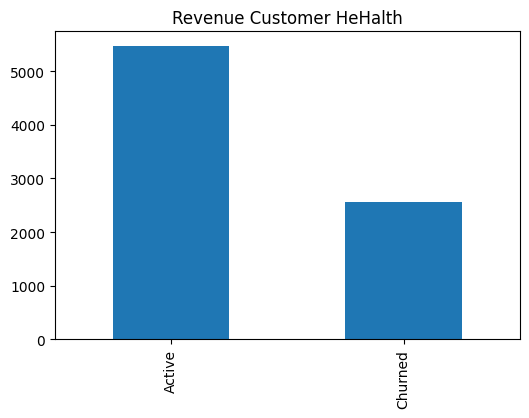

In [11]:
HEALTH = pd.Series({

    "Active":
    ACTIVE_REVENUE_CUSTOMERS,

    "Churned":
    CHURNED_REVENUE_CUSTOMERS
})

HEALTH.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title(
    "Revenue Customer HeHalth"
)

plt.show()

In [12]:
CHURN_EVENTS[
    "churn_reason"
].value_counts()

churn_reason
product_fit    2038
other          1987
budget         1937
price          1932
competitor     1863
Name: count, dtype: int64

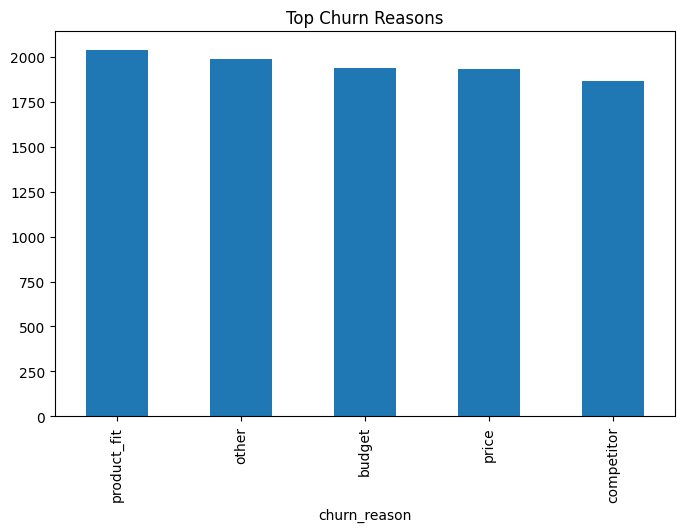

In [13]:
CHURN_EVENTS[
    "churn_reason"
].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Top Churn Reasons"
)

plt.show()

In [14]:
CUSTOMER_HEALTH[
    "industry"
].value_counts()

industry
tech       6352
retail     6265
finance    6214
health     6169
Name: count, dtype: int64

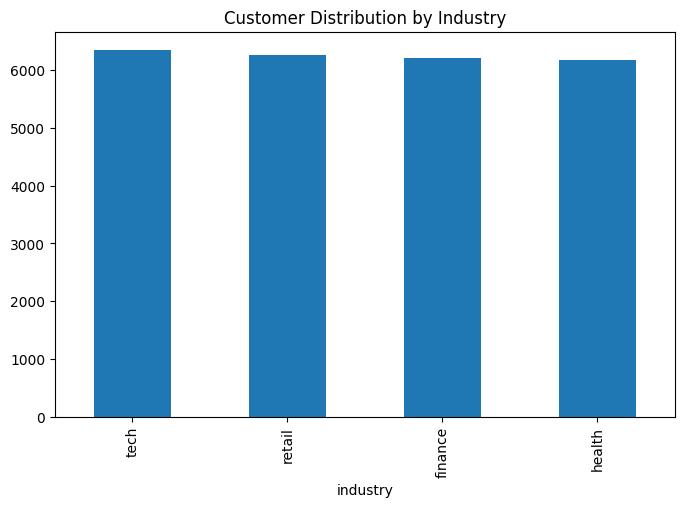

In [15]:
CUSTOMER_HEALTH[
    "industry"
].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Customer Distribution by Industry"
)

plt.show()

In [16]:
CUSTOMER_HEALTH[
    "company_size"
].value_counts()

company_size
small     8444
medium    8348
large     8208
Name: count, dtype: int64

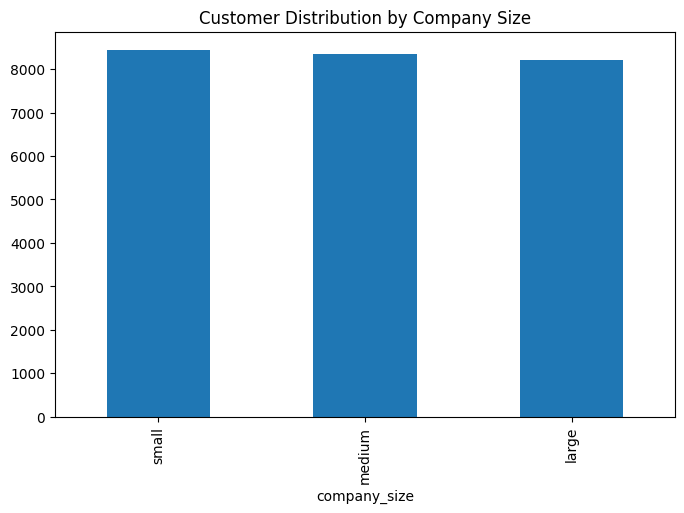

In [17]:
CUSTOMER_HEALTH[
    "company_size"
].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Customer Distribution by Company Size"
)

plt.show()

In [18]:
CUSTOMER_REVENUE = (
    INVOICES
    .groupby("customer_id")["amount"]
    .sum()
)

print(
    CUSTOMER_REVENUE.describe()
)

count    8027.000000
mean      431.317927
std       505.894341
min        19.000000
25%       133.000000
50%       245.000000
75%       490.000000
max      3465.000000
Name: amount, dtype: float64


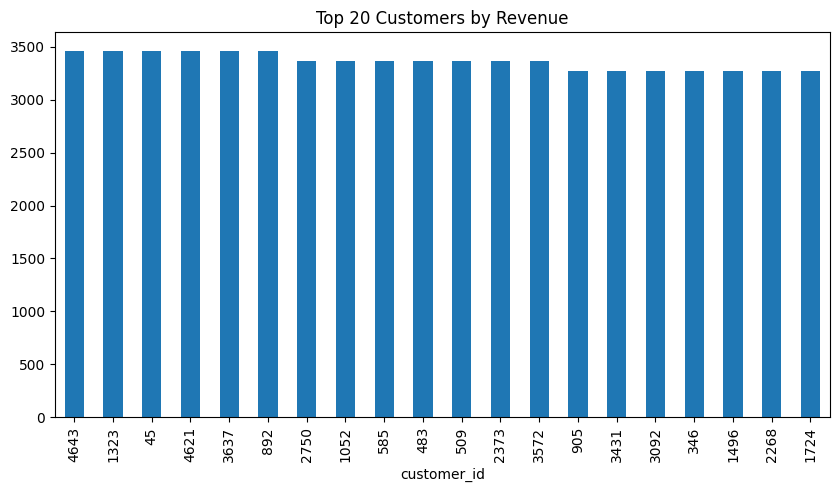

In [19]:
TOP20 = (
    CUSTOMER_REVENUE
    .sort_values(
        ascending=False
    )
    .head(20)
)

TOP20.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 20 Customers by Revenue"
)

plt.show()

In [20]:
TOTAL_REVENUE = (
    INVOICES[
        INVOICES["status"]
        ==
        "paid"
    ]["amount"]
    .sum()
)

REVENUE_PER_ACTIVE_CUSTOMER = (
    TOTAL_REVENUE
    /
    ACTIVE_REVENUE_CUSTOMERS
)

print(
    "REVENUE PER ACTIVE CUSTOMER:",
    round(
        REVENUE_PER_ACTIVE_CUSTOMER,
        2
    )
)

REVENUE PER ACTIVE CUSTOMER: 633.06


In [23]:
RETENTION_RATE = (
    ACTIVE_REVENUE_CUSTOMERS /
    REVENUE_CUSTOMERS
) * 100

print(
    "REVENUE CUSTOMER RETENTION RATE:",
    round(
        RETENTION_RATE,
        2
    ),
    "%"
)

print(
    "CHURN RATE:",
    round(
        CHURN_RATE,
        2
    ),
    "%"
)

REVENUE CUSTOMER RETENTION RATE: 68.13 %
CHURN RATE: 31.87 %


In [24]:
KPI_SUMMARY = pd.DataFrame({

    "KPI":[
        "Revenue Customers",
        "Active Revenue Customers",
        "Churned Revenue Customers",
        "Churn Rate",
        "Revenue Per Active Customer",
        "NRR",
        "GRR"
    ],

    "VALUE":[
        REVENUE_CUSTOMERS,
        ACTIVE_REVENUE_CUSTOMERS,
        CHURNED_REVENUE_CUSTOMERS,
        round(CHURN_RATE,2),
        round(REVENUE_PER_ACTIVE_CUSTOMER,2),
        NRR,
        GRR
    ]
})

KPI_SUMMARY

,KPI,VALUE
0,Revenue Customers,8027.00
1,Active Revenue Customers,5469.00
2,Churned Revenue Customers,2558.00
3,Churn Rate,31.87
4,Revenue Per Active Customer,633.06
5,NRR,58.00
6,GRR,53.00


CUSTOMER & RETENTION INSIGHTS

1. Total customer base consists of 25,000 customers.

2. Revenue is generated by 8,027 customers.

3. Active revenue customers total 5,469, resulting in a retention rate of 68.13%.

4. Churned revenue customers total 2,558, leading to a churn rate of 31.87%.

5. Product fit and budget constraints remain the primary churn drivers.

6. Revenue per active customer exceeds 633.

7. Revenue concentration remains diversified, reducing dependency on a small number of customers.

8. Improving onboarding and product adoption can directly improve retention and recurring revenue performance.